Final TLFs for the website. Some stuff copied over from `eda.ipynb`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
data = pd.read_csv("data/eda_data.csv")
data.shape

(1804, 190)

In [12]:
# Remove individuals with null exposure but measured outcome. 
visit_prefix = ['HORMUSER', 'SPBMDT', 'HPBMDT'] 
throw_away_index = []
for i in range(2, 11):
    visit_i_col = [prefix + str(i) for prefix in visit_prefix]
    visit_i = data[visit_i_col]
    visit_i_temp = visit_i[visit_i[visit_i_col[0]].isna()].notna()
    visit_i_unique_nulls = visit_i_temp[visit_i_temp[visit_i_col[1]] | visit_i_temp[visit_i_col[2]]]
    throw_away_index.append(visit_i_unique_nulls.index.tolist())
data_no_null_hormuser = data.iloc[data.index.difference(sorted(sum(throw_away_index, [])))]
data_no_null_hormuser.shape

(1799, 190)

In [13]:
# Number of individuals per exposure group per visit 

hormuser = ['HORMUSER' + str(i) for i in range(0, 11)]
test = pd.melt(data[hormuser]).reset_index().groupby(['value', 'variable']).count().reset_index()
test_counts = pd.pivot_table(test, values='index', index='value', columns='variable', aggfunc='sum')
test_counts.loc['Total'] = test_counts.sum()
test_counts['HORMUSER10'] = test_counts.pop('HORMUSER10')
test_counts.index.names = ['No. of women']
test_counts.columns.names = ['Visit']
test_counts.reset_index(inplace=True)
test_counts.loc[:, 'No. of women'] = [0, 1, 'Total']
test_counts = test_counts.set_index('No. of women').fillna(0).astype(int)
test_counts

Visit,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
No. of women,,,,,,,,,,,
0,1804,1682,1495,1389,1314,1258,1276,1366,1374,1397,1399
1,0,122,204,260,306,338,340,216,160,133,125
Total,1804,1804,1699,1649,1620,1596,1616,1582,1534,1530,1524


In [15]:
df = pd.DataFrame([['A', 10, 20, 10, 30], ['B', 20, 25, 15, 25], ['C', 12, 15, 19, 6],
                   ['D', 10, 29, 13, 19]],
                  columns=['Team', 'Round 1', 'Round 2', 'Round 3', 'Round 4'])
df

,Team,Round 1,Round 2,Round 3,Round 4
0,A,10,20,10,30
1,B,20,25,15,25
2,C,12,15,19,6
3,D,10,29,13,19


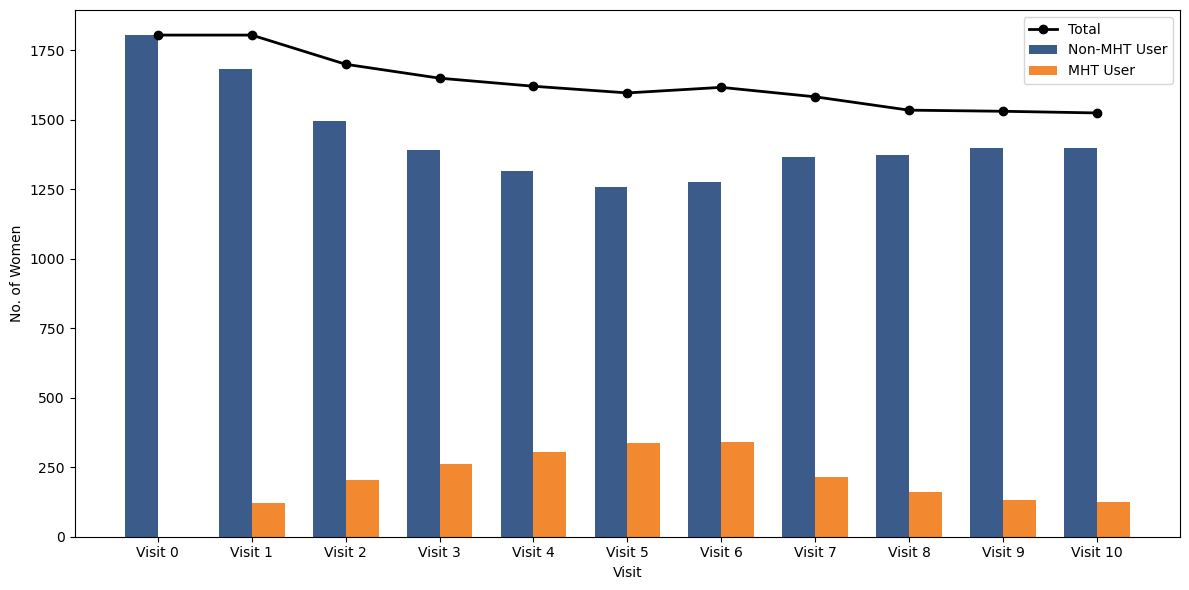

In [28]:
visits = ["Visit " + str(i) for i in range(0, 11)]
nonuser_count = test_counts.iloc[0].values
user_count = test_counts.iloc[1].values
total_count = test_counts.iloc[2].values

x = np.arange(len(visits))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
bars_nonuser = ax.bar(x - width/2, nonuser_count, width, label = "Non-MHT User", color = "#3b5b8a")
bars_user = ax.bar(x + width/2, user_count, width, label = "MHT User", color = "#f28830")
ax.plot(x, total_count, color = "black", marker = "o", linewidth = 2, label = "Total")

ax.set_xlabel("Visit")
ax.set_ylabel("No. of Women")
ax.set_xticks(x)
ax.set_xticklabels(visits)
ax.legend()

plt.tight_layout()
plt.savefig("plots/no_of_women_per_group_per_visit.png")
plt.show()